# 데이터 EDA 및 모델 학습 - 실습

---

## 학습 개요

1. **학습 주제**
  - **탐색적 데이터 분석(EDA)**: 데이터 분포, 상관관계, 결측치·이상치 탐색 및 시각화
  - **머신러닝 기초 개념**: AI/ML/DL 구분, 지도/비지도 학습, 과소·과대적합, 데이터 분할(Train/Valid/Test)
  - **지도학습 분류 모델**: 데이터 전처리, 로지스틱 회귀 학습, 성능 평가 및 교차검증

2. **학습 목표**
  - **머신러닝 기초 개념**을 이해하고 AI/ML/DL, 지도/비지도 학습, 과적합의 차이를 **설명**할 수 있다.
  - pandas, seaborn을 활용해 데이터프레임의 **특성 분포와 상관관계를 시각화**할 수 있다.
  - 결측치와 이상치를 **탐지**하고 적절한 방법으로 **처리**할 수 있다.
  - scikit-learn의 train_test_split 및 StandardScaler로 데이터를 **분할·정규화**할 수 있다.
  - LogisticRegression을 이용해 분류 모델을 **학습**하고, 혼동 행렬·Classification Report·ROC-AUC로 성능을 **평가**할 수 있다.
  - 교차검증으로 모델의 일반화 성능을 **검증**할 수 있다.

3. **핵심 개념**
  - **AI/ML/DL**: 인공지능(AI)은 기계가 지능적으로 행동하도록 만드는 기술, 머신러닝(ML)은 데이터로부터 패턴을 학습하는 AI의 한 방법, 딥러닝(DL)은 신경망을 활용한 ML의 특수 기법
  - **지도학습/비지도학습**: 지도학습은 레이블이 있는 데이터로 예측 모델을 학습, 비지도학습은 레이블 없이 데이터의 패턴/구조를 발견
  - **과소적합/과대적합**: 과소적합은 모델이 너무 단순해 학습 데이터조차 잘 맞추지 못하는 상태, 과대적합은 학습 데이터에만 과도하게 맞춰 새 데이터에서 성능이 떨어지는 상태
  - **Train/Valid/Test 분할**: 학습(Train)은 모델을 훈련시키고, 검증(Valid)은 하이퍼파라미터를 조정하며, 테스트(Test)는 최종 성능을 평가하는 데이터 분할 전략
  - **EDA(탐색적 데이터 분석)**: 데이터 분포, 중앙값·사분위수·상관관계 등을 시각화를 통해 탐색하는 기법
  - **StandardScaler**: 피처별 평균을 0, 분산을 1로 표준화하여 머신러닝 모델 학습을 안정화하는 전처리 기법
  - **Logistic Regression**: 선형 방정식을 기반으로 확률적 분류를 수행하는 지도 학습 알고리즘
  - **교차검증(Cross-Validation)**: 데이터를 여러 폴드로 나누어 반복 학습·평가함으로써 모델의 일반화 성능을 안정적으로 추정

4. **선행 지식**
  - 파이썬 기초 문법(함수, 반복문, 자료구조)
  - NumPy 배열 연산(브로드캐스팅, shape, 벡터화)
  - pandas DataFrame 기본 조작(조회, 집계, 통계)
  - matplotlib/seaborn 기본 시각화

## 실습 구성

1. **학습 방향**

  - **실습 구성 방식**
    - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현합니다.

  - **Required Package**
    ```
    python>=3.11
    numpy>=2.0.0
    pandas>=2.0.0
    matplotlib>=3.8.0
    seaborn>=0.13.2
    scipy>=1.13.0
    scikit-learn>=1.4.2
    ```

  - **Step 요약**
    - **Step 1**: 데이터 로딩 및 탐색적 데이터 분석(EDA) - Wine 데이터셋 로드, 통계량 계산, 상관관계·분포 시각화, 결측치·이상치 탐지 및 처리
    - **Step 2**: 머신러닝 전처리 및 모델 학습 - Train/Test 분할, StandardScaler 적용, Logistic Regression 학습 및 성능 평가
    - **Step 3**: 모델 검증 및 해석 - 교차검증으로 일반화 성능 확인, 차원 축소(PCA) 및 군집화(KMeans)로 데이터 패턴 시각화

2. **데이터셋 개요 및 저작권 정보**
  - **데이터셋 명**: Wine 데이터셋 (load_wine)
  - **데이터셋 개요**: 178개의 와인 샘플에 대해 알코올·산도·플라보노이드 등 13개 화학적 특성을 측정하고, 3개의 클래스(품질)로 라벨링한 다중 분류용 공개 데이터셋
  - **사용 목적**: EDA로 데이터 특성을 파악하고, 이진 분류 모델을 학습·평가하여 머신러닝 파이프라인 전체 흐름을 실습
  - **저작권/출처**: UCI 머신러닝 저장소의 공개 라이선스 데이터로, scikit-learn 패키지 내에서 재배포 및 학습 목적으로 사용 가능

3. **문제 설명**

  - **문제 개요**: 이 실습은 머신러닝의 기초 개념을 이해하고 실무에서 사용하는 ML 파이프라인 전체 흐름을 경험하기 위해 설계되었습니다. 학습자는 **EDA, 데이터 전처리, 모델 학습, 성능 평가**를 코드로 확인하고, 최종적으로 **데이터로부터 인사이트를 도출하고 분류 모델을 학습·평가**할 수 있어야 합니다.

  - **요구사항 요약**
    - **Step 1**: Wine 데이터셋 로드 및 EDA 수행
      - **TODO 1**: 데이터 기본 통계/분포/상관관계를 계산하고 해석하기
      - **TODO 2**: 상관관계 행렬(heatmap) 시각화로 주요 변수 관계 확인하기
      - **TODO 3**: 히스토그램 기반 분포 비교(`hue="quality"` 포함) 수행하기
      - **TODO 4**: scatterplot으로 변수 관계와 클래스 분리 경향 확인하기
      - **TODO 5**: pairplot으로 상위 상관 특성들의 분포/관계 한 번에 점검하기
      - **TODO 6**: 결측치 대체 및 IQR 기반 이상치 제거 처리하기
    - **Step 2**: 데이터 전처리 및 로지스틱 회귀 모델 학습
      - **TODO 7**: train/test 분할 및 StandardScaler 표준화 적용하기
      - **TODO 8**: LogisticRegression 학습 후 confusion matrix / classification report / ROC-AUC 평가하기
    - **Step 3**: 교차검증 및 차원 축소·군집화 분석
      - **TODO 9**: 5-fold 교차검증으로 평균 F1-score 산출하기
      - **TODO 10**: PCA 2차원 축소 및 K-Means 군집화 결과를 실제 라벨과 비교 시각화하기


## Concept Check: Machine Learning 기초개념

**지도학습 vs 비지도학습**

- **지도학습 (Supervised Learning)**
  - 레이블(정답)이 있는 데이터로 모델을 학습시킵니다.
  - 목표: 입력 X가 주어졌을 때 정답 Y를 예측
  - 예: 분류(Classification), 회귀(Regression)
  - 사용 예: 이메일 스팸 분류, 집값 예측, 이미지 분류

- **비지도학습 (Unsupervised Learning)**
  - 레이블 없이 데이터의 패턴이나 구조를 발견합니다.
  - 목표: 데이터를 그룹화하거나 차원을 축소
  - 예: 군집화(Clustering), 차원 축소(PCA, t-SNE)
  - 사용 예: 고객 세분화, 이상치 탐지, 데이터 시각화

---

**과소적합 vs 과대적합**

- **과소적합 (Underfitting)**
  - 모델이 너무 단순해서 학습 데이터조차 잘 맞추지 못하는 상태
  - 학습 데이터와 테스트 데이터 모두에서 성능이 낮습니다.
  - 해결 방법: 모델 복잡도 증가, 특성 추가, 학습 시간 증가

- **과대적합 (Overfitting)**
  - 모델이 학습 데이터에만 과도하게 맞춰져서 새 데이터(테스트)에서 성능이 떨어지는 상태
  - 학습 데이터에서는 성능이 높지만, 테스트 데이터에서는 낮습니다.
  - 해결 방법: 정규화(Regularization), 데이터 증강, 조기 종료(Early Stopping)

- **이상적인 상태**: 학습 데이터와 테스트 데이터 모두에서 적절한 성능을 보이는 균형 상태

---

**Train / Validation / Test 데이터 분할**

머신러닝에서는 데이터를 세 가지로 나누어 사용합니다:

1. **Train (학습 데이터)**
  - 모델을 학습시키는 데 사용
  - 모델은 이 데이터로부터 패턴을 학습합니다.
  - 비율: 보통 60~80%

2. **Validation (검증 데이터)**
  - 하이퍼파라미터를 조정하고 모델을 선택하는 데 사용
  - 학습 중 성능을 모니터링하고 과적합을 방지합니다.
  - 비율: 보통 10~20%
  - 참고: 간단한 실습에서는 Train/Test만 나누고 교차검증으로 Valid 대체 가능

3. **Test (테스트 데이터)**
  - 최종 모델의 성능을 평가하는 데 사용
  - 학습에 전혀 사용되지 않은 "처음 보는 데이터"
  - 비율: 보통 10~20%

**왜 나누나요?**
- 모델이 학습 데이터만 외우지 않고 일반화 성능을 갖추도록 하기 위함
- Test 데이터는 "실전 성능"을 측정하는 용도로, 학습에 절대 사용하면 안 됩니다.

---

**머신러닝 학습 파이프라인 (프레임워크)**

일반적인 머신러닝 프로젝트는 다음과 같은 흐름으로 진행됩니다:

1. **데이터 수집 및 이해**
  - 문제 정의 및 데이터 수집
  - EDA를 통해 데이터 분포, 결측치, 이상치 파악

2. **데이터 분할 (Train/Valid/Test)**
  - 학습/검증/테스트 데이터로 분리
  - stratify 옵션으로 클래스 비율 유지

3. **데이터 전처리**
  - 결측치 처리, 이상치 제거
  - 스케일링(Normalization, Standardization)
  - 특성 엔지니어링(Feature Engineering)

4. **모델 학습 (Training)**
  - 적절한 알고리즘 선택
  - 하이퍼파라미터 설정 및 학습

5. **모델 평가 (Evaluation)**
  - 성능 지표 계산 (정확도, F1-score, ROC-AUC 등)
  - 교차검증으로 일반화 성능 확인

6. **결과 해석 및 개선**
  - 혼동 행렬, Feature Importance 등으로 모델 해석
  - 하이퍼파라미터 튜닝, 모델 앙상블 등으로 성능 개선

이번 실습에서는 이 전체 파이프라인을 Wine 데이터셋으로 직접 경험해봅니다!

## Install & Import

In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "pandas>=2.0.0" \
    "matplotlib>=3.8.0" \
    "seaborn>=0.13.2" \
    "scipy>=1.13.0" \
    "scikit-learn>=1.4.2"


In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# 데이터 불러오기
df, y = load_wine(as_frame=True, return_X_y=True)
df["quality"] = y

## Step 1: 데이터 로딩 및 탐색적 데이터 분석(EDA)

### Concept Check

지난번까지는 데이터의 특성을 살펴보지 않고 곧바로 데이터를 간단한 전처리만 진행한 후 모델에 넣어서 학습시켰습니다. 하지만 이렇게 아름다운 경우는 현실에서 존재할 수 없습니다. 데이터는 늘 더럽고 사람을 힘들게 합니다. 실제로 여러분이 생각하는 모델링의 과정보다, 데이터를 처리하고 정리하는데 더 많은 시간을 쏟을 수 있습니다. 인공지능 분야에서는 자주 쓰이는 말인 "Trash in, trash out", 즉 쓰레기를 넣으면 쓰레기가 나온다라는 뜻인데요, 그만큼 데이터를 정제하는 것이 얼마나 중요한지 나타냅니다.

이렇게 중요한 데이터, 어떠한 특성을 가지는지 살펴보는 것이 바로 그 시작이라 할 수 있습니다. 오늘은 `sklearn`에서 손쉽게 얻을 수 있는 데이터인 `wine` 데이터셋을 통해 실습을 진행할 예정입니다. 과정은 다음과 같습니다.

1. 데이터를 살펴봅니다. 실습을 통해 여태까지 배운 `pandas` 기술들을 뽐내봅시다.
2. 데이터를 시각화해봅니다.
3. 데이터 전처리에 대해서 추가적으로 학습합니다.
4. `sklearn`을 이용해 이번에는 손쉽게 모델을 학습시킵니다.

**EDA (탐색적 데이터 분석)란?**
- 데이터의 분포, 통계량, 관계를 시각화하여 데이터의 특성을 이해하는 과정
- pandas DataFrame : 테이블 형태로 데이터를 저장하고 요약 통계, 데이터 선택·조작 기능을 제공
- numpy 배열 연산 : 배열 기반 고속 수치 연산과 통계 함수(평균·표준편차·히스토그램 등)를 지원
- seaborn 히트맵 : 상관계수 행렬을 색상으로 표현해 피처 간 상관관계를 직관적으로 파악
- seaborn histplot : 변수별 분포를 히스토그램과 KDE(커널 밀도 추정)로 동시에 시각화
- seaborn scatterplot : 이변량 산점도를 그려 변수 간 관계와 카테고리별 분포 차이를 표현
- pairplot : 여러 피처 쌍에 대한 산점도·분포도를 한 번에 그려 상관관계와 분포 형태를 종합 탐색

### TODO 1: 데이터 파헤치기

위에서 `wine` 데이터셋을 성공적으로 불러왔습니다. 해당 데이터셋은 여러 특성을 통해 와인의 퀄리티를 맞추는 과제입니다. 타깃 변수인 y를 임의로 제가 데이터프레임에 `quality`라는 컬럼으로 할당하였습니다.

이제 그동안 배운 `pandas` 라이브러리를 활용하여 아래 문제들을 하나씩 풀어보세요. 정답 확인용 코드인 `assert` 문은 수정 없이 사용하시면 됩니다.

- **요구사항**: 각 문제에서 요구하는 값을 계산하여 변수에 할당하세요.

In [3]:
# 1. 이 데이터셋에 포함된 와인의 총 샘플 수를 구해서 sample_count 변수에 담아주세요!
sample_count = len(df)
assert sample_count == 178, f"총 샘플 수는 178이어야 합니다. (got {sample_count})"

# 2. 이 데이터셋에 포함된 특성(feature) 수를 구해서 feature_count 변수에 담아주세요!
feature_count = df.shape[1]
assert feature_count == 14, f"특성 수는 14이어야 합니다. (got {feature_count})"

# 3. 타깃 변수(y)는 몇 개의 클래스로 구분되는지 구해서 class_count 변수에 담아주세요!
class_count = pd.Series(y).nunique()
assert class_count == 3, f"클래스 개수는 3이어야 합니다. (got {class_count})"

# 4. 각 클래스별 샘플 수를 Series 형태로 구해서 class_distribution 변수에 담아주세요!
class_distribution = pd.Series(y).value_counts().sort_index()
expected_distribution = pd.Series({0: 59, 1: 71, 2: 48})
assert class_distribution.sort_index().equals(expected_distribution.sort_index()), \
    f"클래스 분포가 예상과 다릅니다.\nexpected:\n{expected_distribution}\ngot:\n{class_distribution}"

# 5. Alcohol 평균값이 가장 높은 클래스 번호를 구해서 top_alcohol_class 변수에 담아주세요!
top_alcohol_class = pd.DataFrame({"y": y, "alcohol": df["alcohol"]}).groupby("y")["alcohol"].mean().idxmax()
assert top_alcohol_class == 0, f"Alcohol 평균이 가장 높은 클래스는 0입니다. (got {top_alcohol_class})"

# 6. Malic acid 특성의 평균을 구해서 malic_mean 변수에 담아주세요!
malic_mean = df["malic_acid"].mean()
assert np.isclose(malic_mean, 2.3363483146, atol=1e-3), f"Malic acid 평균이 예상과 다릅니다. (got {malic_mean})"

# 7. Malic acid 특성의 표준편차를 구해서 malic_std 변수에 담아주세요!
malic_std = df["malic_acid"].std(ddof=1)
assert np.isclose(malic_std, 1.1171460976, atol=1e-3), f"Malic acid 표준편차가 예상과 다릅니다. (got {malic_std})"

# 8. Color intensity가 10 이상인 샘플의 비율(%)을 구해서 high_color_ratio 변수에 담아주세요!
high_color_ratio = (df["color_intensity"] >= 10).mean() * 100
assert np.isclose(high_color_ratio, 3.93258427, atol=1e-2), f"Color intensity>=10 비율(%)이 예상과 다릅니다. (got {high_color_ratio})"

# 9. Ash 특성에서 최소값을 가진 샘플의 클래스를 구해서 min_ash_class 변수에 담아주세요!
min_ash_idx = df["ash"].idxmin()
min_ash_class = int(y.iloc[min_ash_idx] if hasattr(y, "iloc") else pd.Series(y).iloc[min_ash_idx])
assert min_ash_class == 1, f"Ash 최소값을 가진 샘플의 클래스는 1입니다. (got {min_ash_class})"

# 10. Proline 분포에서 가장 높은 피크를 보이는 클래스 번호를 구해서 proline_peak_class 변수에 담아주세요!
bins = 20
global_min, global_max = df["proline"].min(), df["proline"].max()
peak_by_class = {}
y_series = pd.Series(y)
for cls in y_series.unique():
    counts, _ = np.histogram(df.loc[y_series == cls, "proline"], bins=bins, range=(global_min, global_max))
    peak_by_class[int(cls)] = counts.max()
proline_peak_class = max(peak_by_class, key=peak_by_class.get)
assert proline_peak_class == 1, f"Proline 분포 피크가 가장 높은 클래스는 1입니다. (got {proline_peak_class})"

# 11. Magnesium 값이 상위 10%인 샘플들의 평균 Proline 값을 구해서 high_magnesium_proline_mean 변수에 담아주세요!
thresh = df["magnesium"].quantile(0.9)
high_magnesium_proline_mean = df.loc[df["magnesium"] >= thresh, "proline"].mean()
assert np.isclose(high_magnesium_proline_mean, 864.75, atol=1e-2), \
    f"Magnesium 상위 10%의 평균 Proline은 약 864.75입니다. (got {high_magnesium_proline_mean})"

# 12. Alcohol과 가장 상관관계가 높은 특성 이름을 구해서 top_corr_with_alcohol 변수에 담아주세요!
corr_with_alcohol = df.corr(numeric_only=True)["alcohol"].drop("alcohol")
top_corr_with_alcohol = corr_with_alcohol.abs().idxmax()
assert top_corr_with_alcohol == "proline", f"Alcohol과 가장 상관 높은 특성은 'proline'입니다. (got {top_corr_with_alcohol})"
print("✅ 모든 테스트를 통과했습니다!")

✅ 모든 테스트를 통과했습니다!


모든 테스트를 통과하셨나요? 그렇다면 여러분은 기초적인 `pandas`에 대한 사용법은 모두 숙지했다고 볼 수 있습니다. 숫자를 통해 데이터를 모두 살펴보았다면, 이제는 플롯으로 데이터를 살펴봅시다.

### Concept Check: 상관관계

만약 x라는 변수가 커질 때 y라는 변수도 함께 커지는 경향을 띠면 우리는 '상관관계를 보인다'라고 말할 수 있습니다. 상관관계는 우리가 예측하려는 변수와 관계가 높은 특성이 있는 경우 문제를 푸는 데 중요한 열쇠가 될 수 있기 때문에, 상관관계를 살펴보는 것은 굉장히 중요합니다.

일반적으로 가장 접근과 해석이 쉬운 상관관계는 **Pearson 상관계수(Pearson's r)** 로, 두 변수 사이의 선형관계를 -1에서 1 사이로 표현합니다. 선형관계를 살펴보기 때문에 $y=mx$ 형태로 두 변수가 엮여 있다면 높은 상관관계를 보입니다. 다만 $y = x^2$처럼 비선형 관계의 경우, x의 분포에 따라 상관계수가 높게 나올 수도 있고 낮게 나올 수도 있으며, 완벽한 1이 되지는 않습니다.

⚠️ **주의할 점**: _상관관계는 인과관계가 아닙니다._ x와 y가 높은 상관관계를 가진다고 해서 x가 y의 원인이 되지는 않습니다. 예를 들어봅시다. 여름에 아이스크림 판매량이 늘어나고, 동시에 익사 사고도 증가합니다. 둘 사이에는 높은 상관관계가 있지만, 아이스크림이 익사의 원인은 아닙니다.

### TODO 2: 상관관계 시각화

- **요구사항**:
  1. 모든 변수들 사이 상관관계를 `corr`이라는 변수에 담아보세요!
  2. 위에서 만든 `corr`을 `sns.heatmap` 위에 그려보세요. 다음 조건들을 만족해주세요.
     - 변수가 많습니다. Figure size를 키워주세요
     - Heatmap은 한 눈에 상관관계성을 보기에 좋습니다. 하지만 수치적으로 와닿기 위해서 어떤 조치를 취할 수 있을까요? (hint: `annot=True`)
     - 포맷팅을 소수점 두자리까지만 나오게 해주세요
     - colormap은 coolwarm을 사용해주세요.
     - 대각행렬에는 자가 상관계수가 들어갑니다. 즉 어차피 1입니다. 제외하고 보여주세요.
     - 상관계수 행렬은 대칭행렬입니다. 필요한 경우 전체 행렬을 시각화하기도 하지만, 오늘은 아래 부분만 보고 싶네요. 대각행렬을 기준으로 윗부분 제외하고 아랫부분만 보여주세요.
     - 위를 날리고나니 뒤에 있는 grid가 거슬립니다. 없애주세요.
     - 배경을 흰색으로 바꿔주세요.
- **출력예시**:
    <br><br>
    <img src="https://github.com/1pha/image-repo/blob/main/module3/correlation.png?raw=true" alt="Seaborn Example" width="600"/>

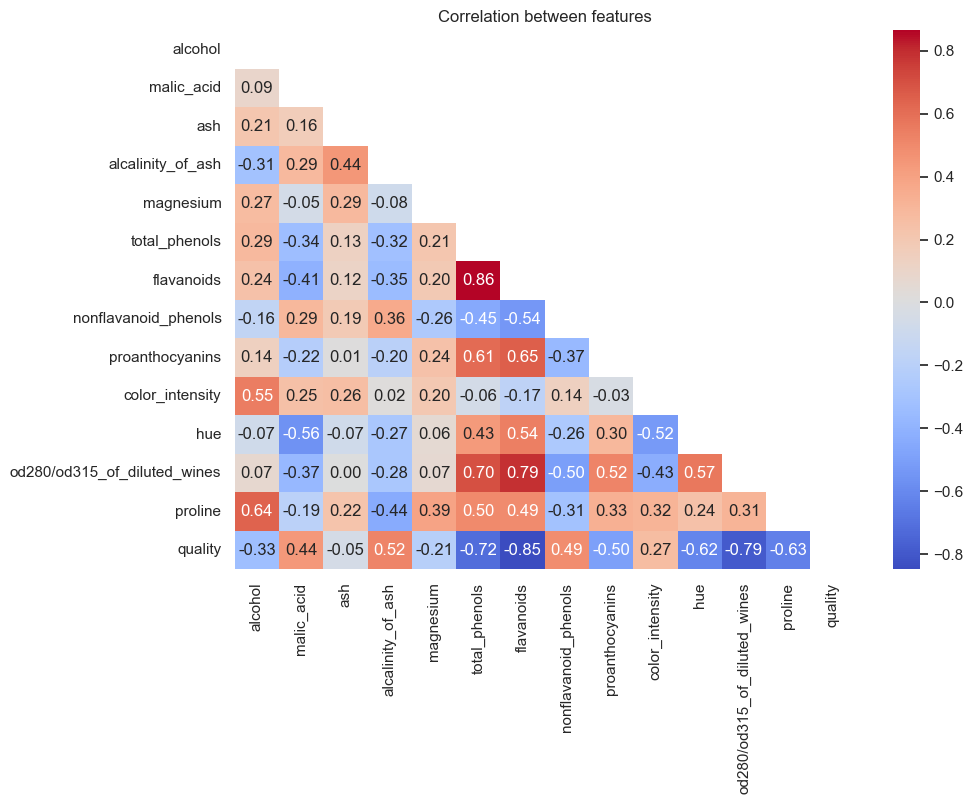

In [4]:
# 1. 모든 변수들 사이 상관관계를 `corr`이라는 변수에 담아보세요!
corr = df.corr()

# 2. 위에서 만든 `corr`의 shape은 정방형태입니다.
# `corr`을 `sns.heatmap` 위에 그려보세요
fig, ax = plt.subplots(figsize=(10, 7))

n = len(corr)
mask = np.triu(np.ones((n, n)))
sns.heatmap(data=corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
ax.grid(False)
ax.set_title("Correlation between features")
ax.set_facecolor("white")
plt.show()

### Concept Check: 분포 살펴보기

도수분포표는 우리가 확인하고자 하는 데이터가 어떤 분포를 가지는지 확인할 수 있습니다. 아래는 가장 기본적인 도수분포표를 그리는 방법입니다.
위에 상관계수를 시각화하는 작업을 다시 살펴봅시다. `quality`와 제일 높은 상관계수를 가지는 변수는 누구인가요? (음의 상관계수가 높은 것 또한 좋은 정보입니다). 이번에는 `flavanoids` 변수의 분포를 확인해봅시다.

⚠️ **주의할 점**: 원래대로라면 `quality`는 범주형 변수이기 때문에 알아서 `.corr()` 메소드 수행 중에 제외되어야 합니다. 하지만 우선은 0, 1, 2가 연속형 변수로 들어가있어 상관관계 확인이 가능합니다. 이 점 주의해주세요

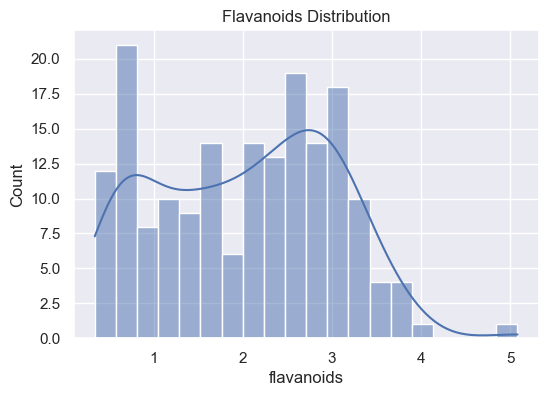

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='flavanoids', bins=20, kde=True)
plt.title('Flavanoids Distribution')
plt.show()

### TODO 3: 다양한 분포 시각화

- **요구사항**: 다음 세 가지 플롯을 각각 ax[0], ax[1], ax[2]에 넣어주세요
  1. 위에서 그린 그림을 세로로 그릴 수도 있을까요?
  2. 클래스별로 flavanoids 어떻게 분포할까요? `hue` argument를 활용해 그려보세요.
  3. flavanoids와 total_phenols를 동시에 histplot에 그려보세요. 이때 `hue="quality"`를 사용해 quality 등급별 색상으로 구분해보세요.

- **출력예시**:
    <br><br>
    <img src="https://github.com/1pha/image-repo/blob/main/module3/histograms.png?raw=true" alt="Seaborn Example" width="600"/>

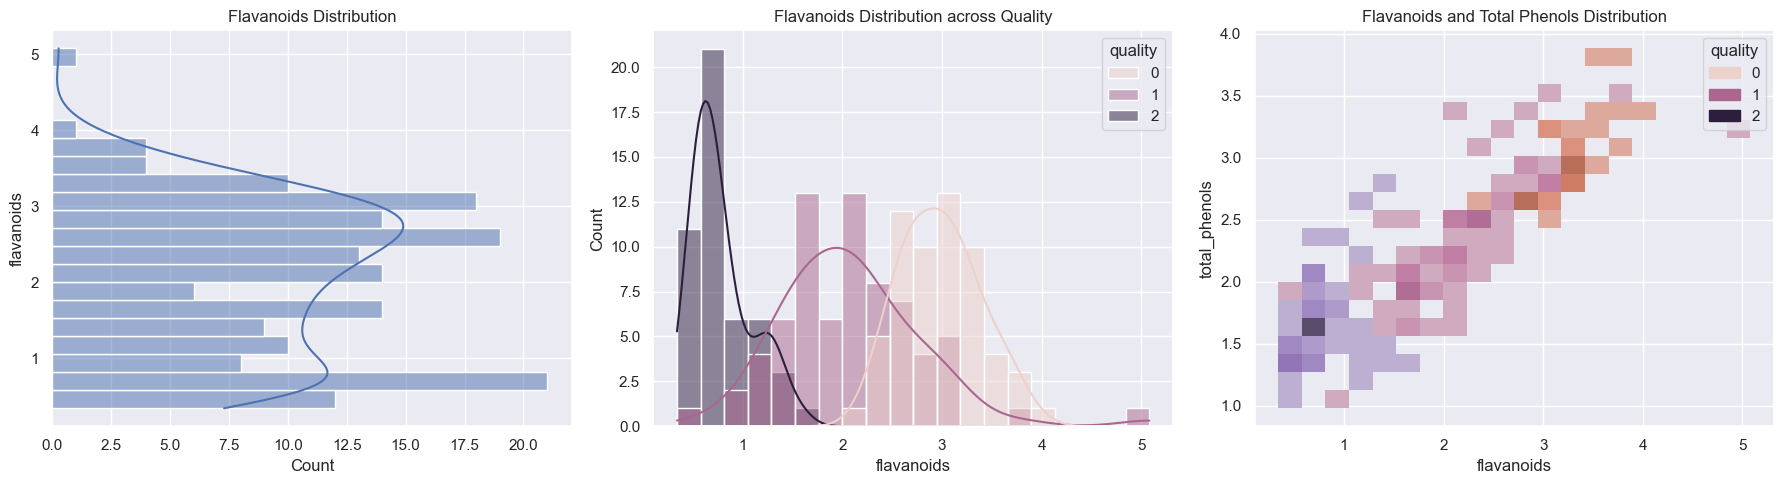

In [6]:
fig, ax = plt.subplots(figsize=(18, 5), ncols=3)

# 1. 위에서 그린 그림을 세로로 그릴 수도 있을까요?
sns.histplot(data=df, y="flavanoids", bins=20, kde=True, ax=ax[0])
ax[0].set_title('Flavanoids Distribution')

# 2. 클래스별로 flavanoids 어떻게 분포할까요?
sns.histplot(data=df, x="flavanoids", hue="quality", bins=20, kde=True, ax=ax[1])
ax[1].set_title('Flavanoids Distribution across Quality')

# 3. flavanoids와 total_phenols를 동시에 histplot에 그릴 수 있을까요?
sns.histplot(data=df, x="flavanoids", y="total_phenols", hue="quality", bins=20, kde=True, ax=ax[2])
ax[2].set_title('Flavanoids and Total Phenols Distribution')

fig.tight_layout()
plt.show()

### TODO 4: scatterplot으로 관계 시각화

- **요구사항**: 위에서 ax[2]에서 그린 그림, 유용하긴한데 좀 다르게 살펴보고 싶은데요? 같은 변수를 [`seaborn.scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)을 통해 그려봅시다.
- **해석 힌트**: scatterplot에서 quality 색이 구간별로 비교적 분리되면, 두 변수(`flavanoids`, `total_phenols`)가 클래스 구분에 유용한 신호일 가능성이 큽니다.
- **출력예시**:
    <br><br>
    <img src="https://github.com/1pha/image-repo/blob/main/module3/scatterplot.png?raw=true" alt="Seaborn Example" width="600"/>

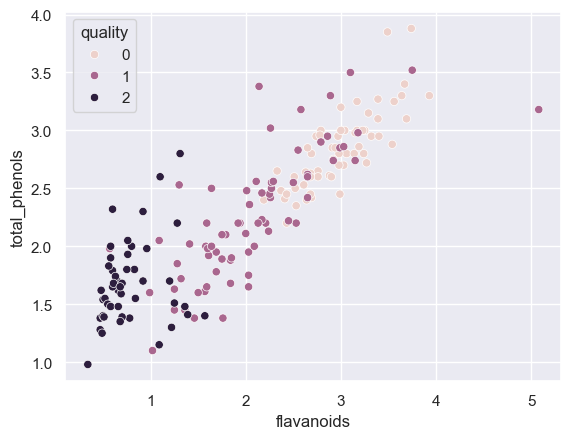

In [7]:
# 위의 예시와 같은 scatterplot을 그려봅시다.
sns.scatterplot(data=df, x="flavanoids", y="total_phenols", hue="quality")
plt.show()

### TODO 5: pairplot으로 한 번에 시각화
이렇게 살펴보니 `flavanoids`가 quality를 나누는데 굉장히 중요한 key가 될 것 같네요. 근데 이렇게 일일이 보니까 귀찮네요. 한 번에 다 그릴 수는 없을까요?
- **해석 힌트**: 대각선은 각 변수의 단일 분포, 비대각선은 변수 간 관계와 quality 분리 정도를 보여줍니다.
- **요구사항**:
    1. 타깃 변수인 `quality`와 상관관계가 가장 높은 5개의 특성을 `top_features`에 할당해주세요.
    2. [`seaborn.pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot)을 통해 `top_features`에 속하는 특성끼리 scatterplot을 모두 한 군데에 담아주세요.
- **출력예시**:
    <br><br>
    <img src="https://github.com/1pha/image-repo/blob/main/module3/pairplot.png?raw=true" alt="Seaborn Example" width="600"/>

선택된 feature: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']


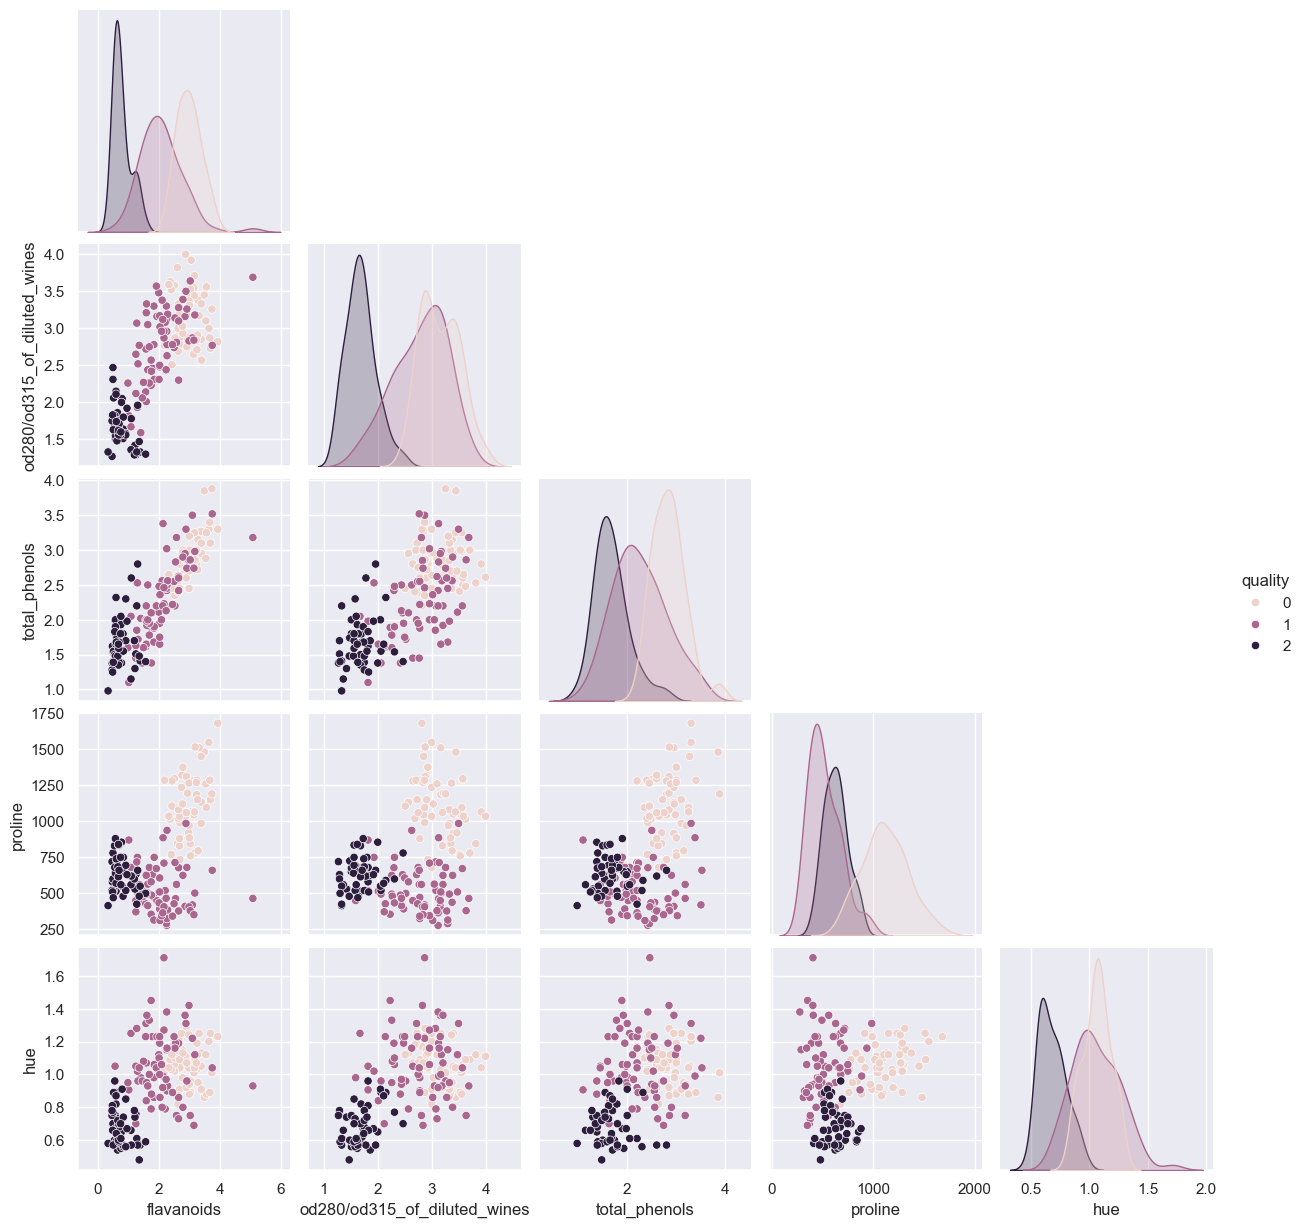

In [8]:
# 1. 타깃 변수인 `quality`와 상관관계가 가장 높은 5개의 특성을 `top_features`에 할당해주세요.
corr_with_quality = corr["quality"].abs().sort_values(ascending=False)
top_features = corr_with_quality.index[1:6]  # quality 제외, 상위 5개
print("선택된 feature:", top_features.tolist())

# 2. seaborn.pairplot을 통해 `top_features`에 속하는 특성끼리 scatterplot을 모두 한 군데에 담아주세요.
plot_df = df[top_features.tolist() + ["quality"]]
sns.pairplot(data=plot_df, hue="quality", corner=True)
plt.show()

### Concept Check: 결측치와 이상치

좋습니다. 이렇게 데이터를 잘 살펴보았습니다. 데이터간 상관관계를 살펴보는 것도 중요하지만, 데이터에 이상이 있는 것도 우리는 늘 살펴봐야합니다. 데이터가 누락되거나 잘못 기입된 경우가 이에 해당합니다. 실제로 데이터를 처리해보시면 이러한 경우가 비일비재하기 때문에 확인하는 것이 필수적입니다. 표준화된 데이터 분석 방식이 존재하진 않으나, 저의 경우 간단하게 시각화를 살펴보고 이상치가 있거나 분포 사이 관계가 너무 좋거나 나쁜 경우 왜 그런지 데이터를 살펴보는 방향을 선택할 때가 많습니다.

이번에는 데이터에서 누락된 경우가 있는지, 혹은 사용할 수 없는 이상치가 있는지 확인하는 코드와 존재하는 경우 어떻게 대처하면 좋은지 실습을 통해 배워봅시다.

참고로 결측치 heatmap에서 흰색(빈 칸) 가로줄처럼 보이는 위치는 해당 행/열에 결측치가 있음을 의미합니다.

In [9]:
# 결측치 이상치 임의생성
df_missing = df.copy()

# 결측치: flavanoids 컬럼의 일부 값을 NaN으로 변경
np.random.seed(42)
missing_idx = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_idx, 'flavanoids'] = np.nan

# 이상치: alcohol 컬럼의 일부 값을 비정상적으로 크게 설정
outlier_idx = np.random.choice(df_missing.index, size=5, replace=False)
df_missing.loc[outlier_idx, 'alcohol'] = df_missing['alcohol'].mean() * 5

alcohol                          0
malic_acid                       0
ash                              0
alcalinity_of_ash                0
magnesium                        0
total_phenols                    0
flavanoids                      10
nonflavanoid_phenols             0
proanthocyanins                  0
color_intensity                  0
hue                              0
od280/od315_of_diluted_wines     0
proline                          0
quality                          0
dtype: int64


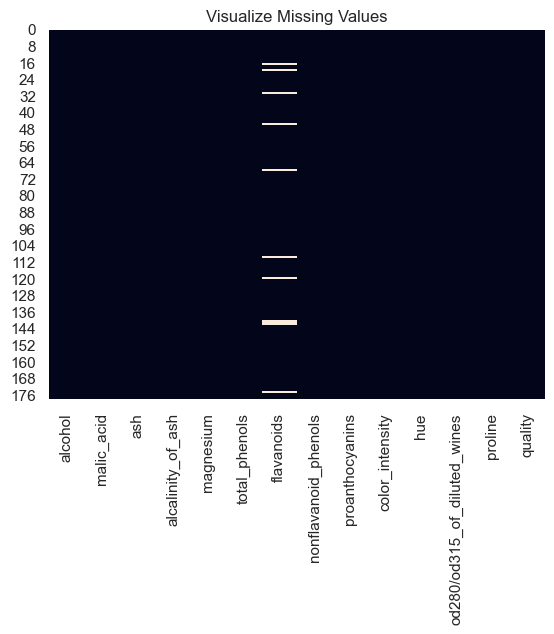

In [10]:
print(df_missing.isnull().sum())

# 시각화로 결측치 확인
sns.heatmap(df_missing.isnull(), cbar=False)
plt.title("Visualize Missing Values")
plt.show()

### Concept Check: IQR 기반 이상치 탐지

이상치는 다른 데이터와 비교했을 때 값이 너무 크거나 작아서 눈에 띄는 데이터를 말합니다. 예를 들어 대부분 사람들이 150~190cm 사이의 키를 가지고 있는데, 250cm가 나온다면 이는 이상치일 가능성이 큽니다. 이상치는 데이터 입력 실수, 측정 오류, 혹은 정말 드문 특별한 경우 때문에 발생할 수 있습니다. 분석 전에 이런 값을 확인하고, 잘못된 값이면 제거하거나 경계값으로 바꾸고, 의미가 있다면 그대로 두는 것이 좋습니다.

**IQR(사분위 범위)** 은 이상치를 찾는 대표적인 방법 중 하나입니다. 먼저 데이터를 작은 값부터 큰 값까지 순서대로 정렬하고, 아래쪽 25% 지점(Q1)과 위쪽 25% 지점(Q3)을 찾습니다. IQR은 Q3에서 Q1을 뺀 값으로, 데이터의 중간 50% 범위를 의미합니다. 이상치는 보통 Q1보다 1.5 × IQR만큼 작거나, Q3보다 1.5 × IQR만큼 큰 값으로 정의합니다. 이 방법은 평균과 표준편차를 쓰는 방법보다 극단값에 덜 민감하고, 데이터가 정규분포를 따르지 않아도 사용할 수 있다는 장점이 있습니다.

예를 들어 boxplot에서 대부분의 alcohol 값이 10~15 부근에 몰려 있는데 60대 값이 보이면, 이는 IQR 기준으로 강한 이상치 후보입니다.

alcohol 이상치 개수: 5


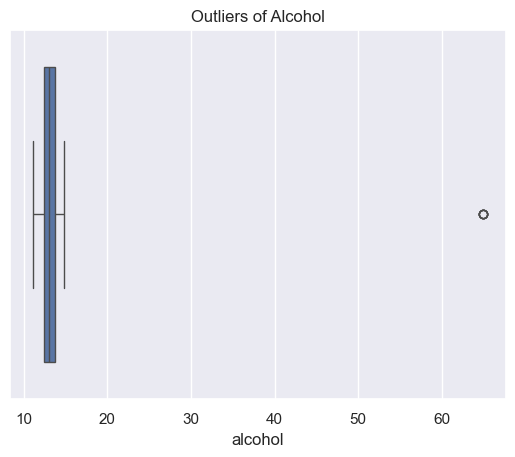

In [11]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers_alcohol = detect_outliers_iqr(df_missing, 'alcohol')
print(f"alcohol 이상치 개수: {len(outliers_alcohol)}")

# boxplot으로 이상치 확인
sns.boxplot(x=df_missing['alcohol'])
plt.title("Outliers of Alcohol")
plt.show()

### Concept Check: 결측치와 이상치 처리 방법

**결측치(Missing Value)와 이상치(Outlier)** 는 데이터 분석에서 반드시 먼저 확인하고 처리해야 하는 부분입니다.

**결측치 처리 방법**:
1. **삭제**: 결측치가 있는 행이나 열을 통째로 삭제 (데이터가 충분히 많을 때 유용)
2. **대체(Imputation)**:
  - 평균값, 중앙값, 최빈값으로 채우기
  - 시계열: 이전 값이나 다음 값으로 채우기
  - 고급: 머신러닝 모델로 예측해 채우기

**이상치 처리 방법**:
1. **삭제**: 명백히 잘못된 값이면 해당 데이터를 삭제
2. **변환**: 로그 변환이나 제곱근 변환 등을 통해 데이터 분포를 조정
3. **대체**: 이상치를 상한·하한 경계값으로 바꾸거나 평균·중앙값으로 대체

**중요**: 무조건 제거하거나 바꾸기 전에 **왜 생겼는지**를 먼저 확인하세요. 실측 오류라면 제거하는 것이 맞지만, 의미 있는 값이라면 보존하거나 변환하는 것이 더 적절합니다.

### TODO 6: 결측치 및 이상치 처리

- **요구사항**:
  1. 결측치를 평균값으로 대체하여 `df_filled`에 할당해주세요.
  2. 이상치를 제거한 데이터를 `df_no_outliers`에 할당해주세요.

In [12]:
# 1. 결측치를 평균값으로 대체하여 `df_filled`에 할당해주세요.
df_filled = df_missing.fillna(df_missing.mean(numeric_only=True))
assert df_filled['flavanoids'].isnull().sum() == 0, "❌ flavanoids 컬럼에 결측치가 남아 있습니다."

# 2. 이상치를 제거한 데이터를 `df_no_outliers`에 할당해주세요.
df_no_outliers = df_filled[~df_filled.index.isin(outliers_alcohol.index)]

# Test code 입니다. 수정없이 사용해주세요.
from scipy.stats import iqr
Q1 = df_filled['alcohol'].quantile(0.25)
Q3 = df_filled['alcohol'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치가 제거된 상태인지 확인
outliers_remaining = df_no_outliers[(df_no_outliers['alcohol'] < lower_bound) | (df_no_outliers['alcohol'] > upper_bound)]
assert len(outliers_remaining) == 0, f"❌ alcohol 컬럼에 이상치가 {len(outliers_remaining)}개 남아 있습니다."

print(f"처리 전 데이터 크기: {df_missing.shape}")
print(f"이상치 제거 후 데이터 크기: {df_no_outliers.shape}")
print("✅ 모든 테스트를 통과했습니다!")

처리 전 데이터 크기: (178, 14)
이상치 제거 후 데이터 크기: (173, 14)
✅ 모든 테스트를 통과했습니다!


## Step 2: 머신러닝 전처리 및 모델 학습

### Concept Check

좋습니다. 현재까지 데이터를 살펴보고 이상치/결측치가 존재하는 경우 어떻게 처리하면 되는지에 대해 배워보았습니다. 아직까지 모델링을 진행하지 않은 사실, 깨달으셨나요?

우리가 지난번에 작성한 수많은 코드들을 다시 작성할 필요는 없습니다. 왜냐하면 이 모든 일들을 미리 수행해둔 `scikit-learn`이 있기 때문이죠. `scikit-learn`은 데이터의 전처리와 간단한 머신러닝 모듈들을 빠르게 구현할 수 있도록 도와주는 라이브러리입니다. 대부분의 모듈은 다음과 같은 파이프라인으로 구동됩니다.

**scikit-learn 파이프라인**:
1. Instance 선언
2. `.fit()`을 통한 매개변수 학습 혹은 초매개변수 설정
3. 2.에서 최적화한 매개변수들을 이용해 `.predict()`를 통한 모델 예측, 혹은 설정된 초매개변수를 통한 `.transform()` 수행

간단하게 전처리를 수행해볼까요?

### TODO 7: sklearn을 통한 데이터 전처리

강의와 챕터 0에서 우리는 전체 데이터를 학습에 사용하는 것이 아닌 일부 데이터만을 사용하여 처음 보는 데이터에 대한 모델의 성능을 확인하는 것이 중요하다는 점을 배웠습니다. 따라서 데이터를 `train`용과 `test`용으로 나눠보는 것으로 시작해봅시다.

그리고 `train` 데이터에 대해 데이터 표준화를 진행하고, 여기에 사용된 평균/표준편차를 통해 `test` 데이터 또한 표준화하는 과정을 거칩니다.

- **왜 표준화가 중요할까요?**
  - 로지스틱 회귀는 최적화 과정에서 특성 스케일 차이에 민감해 수렴 속도와 안정성이 달라질 수 있습니다.
  - L1/L2 규제는 계수 크기에 직접 작용하므로, 표준화하지 않으면 큰 스케일 특성이 과도한 영향을 줄 수 있습니다.

- **요구사항**:
  1. Train/test 데이터를 나누어 `X_train`, `X_test`, `y_train`, `y_test`에 할당해주세요.
     1. test data는 전체 데이터 중 30%로 설정해주세요
     2. 데이터 분할의 결과를 `random_state`를 통해 고정시켜주세요.
     3. 훈련 데이터에는 전부 0이, 검증 데이터에는 전부 1이 들어가는 것을 방지해주세요.
  2. `StandardScaler`를 사용해 표준화를 진행해주세요.
- **힌트**: [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [13]:
X = df.drop("quality", axis=1).values.copy()
y = df["quality"].values.copy()
y[y == 0] = 0
y[y != 0] = 1

# 1. Train/test 데이터를 나누어 `X_train`, `X_test`, `y_train`, `y_test`에 할당해주세요.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)

# 2. `StandardScaler`를 사용해 표준화를 진행해주세요.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

### TODO 8: sklearn을 통한 모델 훈련 및 검증

좋습니다. 성공적으로 train/test 데이터를 나누고 전처리까지 수행하였습니다. 이제는 모델링을 진행해봅시다. 아까 설명한 `sklearn` 모듈들의 파이프라인을 숙지하면 됩니다. API Reference를 잘 살펴보면 좋습니다.

- **요구사항**:
  1. [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) 모델을 선언해서 `clf`에 할당해주세요.
  2. `.fit` 메소드를 통해 모델을 학습시켜주세요
  3. `X_test`를 예측해서 `y_pred`에 할당해주세요
  4. 이진분류 과제를 [여러 가지 평가지표](https://scikit-learn.org/stable/api/sklearn.metrics.html#classification-metrics)로 평가해봅시다.
- **참고**: [ConvergenceWarning?](https://www.slingacademy.com/article/understanding-scikit-learns-convergencewarning-and-how-to-resolve-it/)

- **해석 힌트 (Confusion Matrix)**:
  - 대각선 값(정분류)이 클수록 좋고, 비대각선 값(오분류)이 어떤 클래스 쌍에서 큰지 확인하세요.
  - precision/recall/F1-score를 함께 보면 어떤 오류 유형(과검출/미검출)이 많은지 파악하기 쉽습니다.

[[18  0]
 [ 1 35]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.97      0.99        36

    accuracy                           0.98        54
   macro avg       0.97      0.99      0.98        54
weighted avg       0.98      0.98      0.98        54



/opt/homebrew/anaconda3/envs/bcamp/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


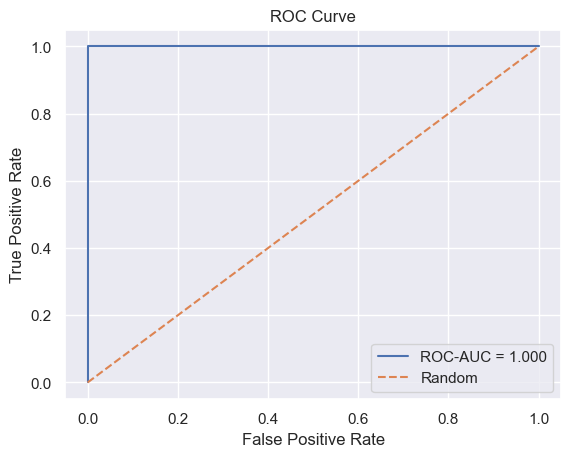

In [14]:
# 1. `sklearn.linear_model.LogisticRegression` 모델을 선언해서 `clf`에 할당해주세요.
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

# 2. `.fit` 메소드를 통해 모델을 학습시켜주세요
clf.fit(X_train, y_train)

# 3. `X_test`를 예측해서 `y_pred`에 할당해주세요
y_pred = clf.predict(X_test)

# 4. 이진분류 과제를 여러 가지 평가지표로 평가해봅시다.
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ROC-AUC 그리기
from sklearn.metrics import roc_curve, roc_auc_score

# 양성(1) 클래스의 "점수" 얻기: 가능하면 확률, 없으면 decision_function 점수
y_score = clf.predict_proba(X_test)[:, 1]

# FPR, TPR, 임계값과 AUC 계산
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

# ROC 곡선 시각화 (matplotlib 사용)
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Step 3: 모델 검증 및 해석

### Concept Check: 교차검증(Cross-Validation)

**교차검증(Cross-Validation)** 은 모델의 성능을 더 신뢰성 있게 평가하기 위해 데이터를 여러 번 나누어 학습과 검증을 반복하는 방법입니다. 단순히 한 번의 train/test 분할만으로 성능을 측정하면, 우연히 데이터가 편향되어 들어가서 평가 결과가 과대 또는 과소 추정될 수 있습니다.

교차 검증은 데이터를 여러 개의 폴드(fold)로 나눈 뒤, 각 폴드가 한 번씩 검증 데이터가 되도록 순환하며 학습과 평가를 진행합니다. 이렇게 얻은 여러 번의 점수를 평균하면, 데이터 분할에 따른 편차를 줄이고 모델의 일반화 성능을 더 안정적으로 추정할 수 있습니다.

### TODO 9: sklearn을 통한 교차 검증

**요구사항**: `sklearn.model_selection.cross_val_score`를 통해 5-fold 교차검증을 진행하고, 평균 F1-score를 산출하여 `f1_scores`에 할당해주세요.

In [15]:
# `sklearn.model_selection.cross_val_score`를 통해 5-fold 교차검증을 진행하고, 평균 F1-score를 산출하세요
from sklearn.model_selection import cross_val_score
f1_scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=5, scoring='f1')
print("Average F1-score (CV):", f1_scores.mean())

Average F1-score (CV): 0.957105563633078


/opt/homebrew/anaconda3/envs/bcamp/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/anaconda3/envs/bcamp/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

### Concept Check: PCA와 KMeans

**PCA(주성분 분석)** 는 데이터의 차원을 줄여서 주요한 패턴을 두세 개의 축으로 표현해 주는 기법입니다. 이렇게 하면 고차원 데이터라도 2차원이나 3차원에서 쉽게 시각화할 수 있어, 데이터의 분포나 구조를 직관적으로 파악할 수 있습니다.

**KMeans**는 비지도 학습 기반의 군집화 알고리즘으로, 데이터들을 유사한 특성을 가진 그룹(클러스터)으로 나눕니다. PCA로 축소한 데이터를 KMeans에 적용하면, 데이터가 어떤 기준으로 묶이는지 시각적으로 쉽게 확인할 수 있습니다.

즉, 이 코드는 고차원 데이터를 이해하기 쉽게 줄이고(PCA), 그 안에서 자연스럽게 형성되는 그룹을 찾아내어(KMeans) 시각적으로 표현하기 위해 필요합니다. 이를 통해 데이터의 숨겨진 패턴이나 구조를 발견할 수 있고, 이후 분석 방향을 세우는 데 큰 도움을 줍니다.

### TODO 10: sklearn을 통한 PCA 분석

- **요구사항**:
  1. PCA: 특성을 `sklearn.decomposition.PCA`로 분석해 두 개의 Feature로 축소한 `X_pca`를 만들어주세요.
  2. K-Means: PCA로 축소된 데이터 `X_pca`를 `sklearn.cluster.KMeans`로 2개의 클래스로 군집화해보세요. 얻은 라벨을 `y_cluster`에 할당해주세요.
  3. 시각화: 축소된 두 개의 성분 중 첫 번째 성분을 x축, 두 번째 성분을 y축에 시각화해주세요.
       1. ax[0]에는 PCA결과로부터 K-Means로 추론된 라벨
       2. ax[1]에는 PCA결과에 실제 라벨을 그려놓은 것
- **해석 힌트**:
  - 왼쪽(ax[0])은 비지도 학습(K-Means) 결과, 오른쪽(ax[1])은 실제 라벨입니다.
  - 두 그림의 분리 방향이 비슷하면 PCA 공간에서도 클래스 구조가 유지되며, K-Means가 주요 분리 방향을 잘 포착한 것으로 볼 수 있습니다.


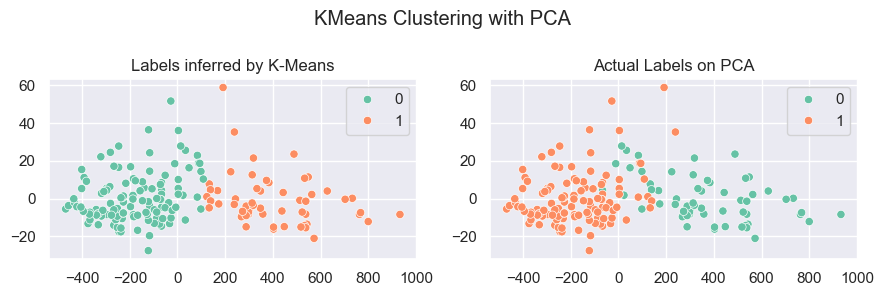

In [16]:
# 1. PCA: 특성을 `sklearn.decomposition.PCA`로 분석해 두 개의 Feature로 축소한 `X_pca`를 만들어주세요.
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # (데이터수, 2)

# 2. K-Means: PCA로 축소된 데이터 `X_pca`를 `sklearn.cluster.KMeans`로 2개의 클래스로 군집화해보세요. 얻은 라벨을 `y_cluster`에 할당해주세요.
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
y_cluster = kmeans.fit_predict(X_pca)

# 3. 시각화: 축소된 두 개의 성분 중 첫 번째 성분을 x축, 두 번째 성분을 y축에 시각화해주세요.
fig, ax = plt.subplots(figsize=(9, 3), ncols=2)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_cluster, palette='Set2', ax=ax[0])
ax[0].set_title("Labels inferred by K-Means")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set2', ax=ax[1])
ax[1].set_title("Actual Labels on PCA")

fig.suptitle('KMeans Clustering with PCA')
fig.tight_layout()
plt.show()

## **학생용 자가 체크리스트**

- [ ] AI, ML, DL의 차이를 설명할 수 있다.
- [ ] 지도학습과 비지도학습의 차이를 설명할 수 있다.
- [ ] 과소적합과 과대적합의 차이를 설명할 수 있다.
- [ ] Train/Valid/Test 분할의 목적을 설명할 수 있다.
- [ ] pandas를 활용해 데이터의 통계량을 계산할 수 있다.
- [ ] seaborn을 활용해 상관관계 히트맵을 그릴 수 있다.
- [ ] 결측치를 탐지하고 적절한 방법으로 처리할 수 있다.
- [ ] IQR 기반 이상치 탐지 방법을 구현할 수 있다.
- [ ] train_test_split으로 데이터를 분할할 수 있다.
- [ ] StandardScaler로 데이터를 정규화할 수 있다.
- [ ] LogisticRegression으로 분류 모델을 학습시킬 수 있다.
- [ ] confusion_matrix, classification_report, ROC-AUC로 모델 성능을 평가할 수 있다.
- [ ] 교차검증으로 모델의 일반화 성능을 확인할 수 있다.
- [ ] PCA로 차원을 축소하고 KMeans로 군집화할 수 있다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.